# Experiment 1: Setting Up the Environment and Data Preprocessing

## 1. Setting Up the Environment

### Installing Required Libraries

In [1]:
# Install all together as suggested in the document
%pip install numpy pandas matplotlib seaborn scikit-learn

### Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Creating a Sample Dataset

In [21]:
# Load dataset from the uploaded 'students.csv' file
data = pd.read_csv("students.csv")
print("Dataset loaded successfully from uploaded 'students.csv'.")

Dataset loaded successfully from uploaded 'students.csv'.


### Loading Dataset Examples (Conceptual - using dummy 'students.csv' above)

In [4]:
# Example of loading an Excel file (conceptual, as students.xlsx does not exist)
# data_excel = pd.read_excel("students.xlsx")

# Example of loading from a database (conceptual)
# import sqlite3
# conn = sqlite3.connect("student.db")
# data_db = pd.read_sql_query("SELECT * FROM Student", conn)

### Viewing the Dataset

In [5]:
print("First five rows:")
display(data.head())

First five rows:


,RollNo,Name,Age,Marks,Gender,Color,Salary
0,101,Asha,20.0,85.0,F,Red,30000.0
1,102,Ravi,21.0,76.0,M,Blue,NaN
2,103,John,20.0,NaN,M,Green,35000.0
3,104,Meena,22.0,91.0,F,Red,40000.0
4,105,Peter,23.0,80.0,M,Blue,45000.0


In [6]:
print("Last five rows:")
display(data.tail())

Last five rows:


,RollNo,Name,Age,Marks,Gender,Color,Salary
4,105,Peter,23.0,80.0,M,Blue,45000.0
5,106,Asha,20.0,85.0,F,Red,30000.0
6,107,Chris,NaN,70.0,M,Green,NaN
7,108,Sara,21.0,88.0,F,Blue,50000.0
8,109,Mike,20.0,75.0,NaN,Red,32000.0


In [7]:
print("Dimensions (rows, columns):")
print(data.shape)

print("\nColumn names:")
print(data.columns.tolist())

print("\nData types:")
print(data.dtypes)

Dimensions (rows, columns):
(9, 7)

Column names:
['RollNo', 'Name', 'Age', 'Marks', 'Gender', 'Color', 'Salary']

Data types:
RollNo      int64
Name       object
Age       float64
Marks     float64
Gender     object
Color      object
Salary    float64
dtype: object


In [8]:
print("Summary information:")
data.info()

Summary information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RollNo  9 non-null      int64  
 1   Name    9 non-null      object 
 2   Age     8 non-null      float64
 3   Marks   8 non-null      float64
 4   Gender  8 non-null      object 
 5   Color   9 non-null      object 
 6   Salary  7 non-null      float64
dtypes: float64(3), int64(1), object(3)
memory usage: 636.0+ bytes


In [9]:
print("Descriptive statistics:")
display(data.describe())

Descriptive statistics:


,RollNo,Age,Marks,Salary
count,9.000000,8.000000,8.000000,7.000000
mean,105.000000,20.875000,81.250000,37428.571429
std,2.738613,1.125992,7.206148,7828.519291
min,101.000000,20.000000,70.000000,30000.000000
25%,103.000000,20.000000,75.750000,31000.000000
50%,105.000000,20.500000,82.500000,35000.000000
75%,107.000000,21.250000,85.750000,42500.000000
max,109.000000,23.000000,91.000000,50000.000000


## 2. Data Preprocessing

### Step 1: Handling Missing Values

In [10]:
print("Missing values before handling:")
print(data.isnull().sum())

Missing values before handling:
RollNo    0
Name      0
Age       1
Marks     1
Gender    1
Color     0
Salary    2
dtype: int64


In [11]:
data_cleaned_drop = data.dropna().copy()
print("\nData after dropping rows with any missing values (first 5 rows):")
display(data_cleaned_drop.head())
print("\nMissing values after dropping:")
print(data_cleaned_drop.isnull().sum())


Data after dropping rows with any missing values (first 5 rows):


,RollNo,Name,Age,Marks,Gender,Color,Salary
0,101,Asha,20.0,85.0,F,Red,30000.0
3,104,Meena,22.0,91.0,F,Red,40000.0
4,105,Peter,23.0,80.0,M,Blue,45000.0
5,106,Asha,20.0,85.0,F,Red,30000.0
7,108,Sara,21.0,88.0,F,Blue,50000.0



Missing values after dropping:
RollNo    0
Name      0
Age       0
Marks     0
Gender    0
Color     0
Salary    0
dtype: int64


In [12]:
data_filled = data.copy()
# Fill numeric columns with mean/median as examples
# 'Age' with mean
data_filled["Age"].fillna(data_filled["Age"].mean(), inplace=True)
# 'Marks' with median
data_filled["Marks"].fillna(data_filled["Marks"].median(), inplace=True)
# 'Salary' with mean
data_filled["Salary"].fillna(data_filled["Salary"].mean(), inplace=True)
# Fill 'Gender' (categorical) with mode
data_filled["Gender"].fillna(data_filled["Gender"].mode()[0], inplace=True)

print("Missing values after filling:")
print(data_filled.isnull().sum())
print("\nData after filling missing values (first 5 rows):")
display(data_filled.head())

Missing values after filling:
RollNo    0
Name      0
Age       0
Marks     0
Gender    0
Color     0
Salary    0
dtype: int64

Data after filling missing values (first 5 rows):


/tmp/ipykernel_1755/1466511839.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_filled["Age"].fillna(data_filled["Age"].mean(), inplace=True)
/tmp/ipykernel_1755/1466511839.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

,RollNo,Name,Age,Marks,Gender,Color,Salary
0,101,Asha,20.0,85.0,F,Red,30000.000000
1,102,Ravi,21.0,76.0,M,Blue,37428.571429
2,103,John,20.0,82.5,M,Green,35000.000000
3,104,Meena,22.0,91.0,F,Red,40000.000000
4,105,Peter,23.0,80.0,M,Blue,45000.000000


### Step 2: Remove Duplicate Data

In [13]:
print("Number of duplicate rows before removal:", data.duplicated().sum())
data_no_duplicates = data.drop_duplicates().copy()
print("Number of duplicate rows after removal:", data_no_duplicates.duplicated().sum())
print("\nData after removing duplicates:")
display(data_no_duplicates)

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0

Data after removing duplicates:


,RollNo,Name,Age,Marks,Gender,Color,Salary
0,101,Asha,20.0,85.0,F,Red,30000.0
1,102,Ravi,21.0,76.0,M,Blue,NaN
2,103,John,20.0,NaN,M,Green,35000.0
3,104,Meena,22.0,91.0,F,Red,40000.0
4,105,Peter,23.0,80.0,M,Blue,45000.0
5,106,Asha,20.0,85.0,F,Red,30000.0
6,107,Chris,NaN,70.0,M,Green,NaN
7,108,Sara,21.0,88.0,F,Blue,50000.0
8,109,Mike,20.0,75.0,NaN,Red,32000.0


### Step 3: Data Type Conversion

In [14]:
print("Original data types for 'Age' and 'Marks':")
print(data_no_duplicates[['Age', 'Marks']].dtypes)

# Convert 'Age' to integer type (ensure no NaNs if converting to non-nullable int)
# For robust conversion, first fill NaNs if any or use nullable integer type
data_no_duplicates['Age'] = data_no_duplicates['Age'].fillna(data_no_duplicates['Age'].mean()).astype(int)

print("\nData types after converting 'Age' to int:")
print(data_no_duplicates[['Age', 'Marks']].dtypes)
display(data_no_duplicates.head())

Original data types for 'Age' and 'Marks':
Age      float64
Marks    float64
dtype: object

Data types after converting 'Age' to int:
Age        int64
Marks    float64
dtype: object


,RollNo,Name,Age,Marks,Gender,Color,Salary
0,101,Asha,20,85.0,F,Red,30000.0
1,102,Ravi,21,76.0,M,Blue,NaN
2,103,John,20,NaN,M,Green,35000.0
3,104,Meena,22,91.0,F,Red,40000.0
4,105,Peter,23,80.0,M,Blue,45000.0


### Step 4: Encoding Categorical Variables

In [15]:
from sklearn.preprocessing import LabelEncoder

data_encoded_label = data_no_duplicates.copy()
# Ensure 'Gender' column has no NaNs for LabelEncoder
data_encoded_label["Gender"] = data_encoded_label["Gender"].fillna(data_encoded_label["Gender"].mode()[0])

le = LabelEncoder()
data_encoded_label["Gender_Encoded"] = le.fit_transform(data_encoded_label["Gender"])
print("Data after Label Encoding 'Gender':")
display(data_encoded_label[['Gender', 'Gender_Encoded']].head())

Data after Label Encoding 'Gender':


,Gender,Gender_Encoded
0,F,0
1,M,1
2,M,1
3,F,0
4,M,1


In [16]:
data_encoded_onehot = data_no_duplicates.copy()
# Ensure 'Color' column has no NaNs if it's going to be one-hot encoded
data_encoded_onehot["Color"] = data_encoded_onehot["Color"].fillna(data_encoded_onehot["Color"].mode()[0])

data_encoded_onehot = pd.get_dummies(data_encoded_onehot, columns=['Color'], prefix='Color')
print("Data after One-Hot Encoding 'Color':")
display(data_encoded_onehot.head())

Data after One-Hot Encoding 'Color':


,RollNo,Name,Age,Marks,Gender,Salary,Color_Blue,Color_Green,Color_Red
0,101,Asha,20,85.0,F,30000.0,False,False,True
1,102,Ravi,21,76.0,M,NaN,True,False,False
2,103,John,20,NaN,M,35000.0,False,True,False
3,104,Meena,22,91.0,F,40000.0,False,False,True
4,105,Peter,23,80.0,M,45000.0,True,False,False


### Step 5: Feature Scaling

In [17]:
from sklearn.preprocessing import StandardScaler

# Using `data_filled` as it has no missing values in numeric columns for scaling demonstration
numeric_data_for_scaling = data_filled[['Age', 'Marks', 'Salary']].copy()

scaler_standard = StandardScaler()
data_scaled_standard = scaler_standard.fit_transform(numeric_data_for_scaling)
data_scaled_standard_df = pd.DataFrame(data_scaled_standard, columns=numeric_data_for_scaling.columns)
print("Data after Standardization (first 5 rows):")
display(data_scaled_standard_df.head())

Data after Standardization (first 5 rows):


,Age,Marks,Salary
0,-0.881140,0.567129,-1.162174
1,0.125877,-0.846331,0.000000
2,-0.881140,0.174501,-0.379942
3,1.132895,1.509435,0.402291
4,2.139912,-0.218127,1.184524


In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()
data_scaled_minmax = scaler_minmax.fit_transform(numeric_data_for_scaling) # Using the same numeric data
data_scaled_minmax_df = pd.DataFrame(data_scaled_minmax, columns=numeric_data_for_scaling.columns)
print("Data after Normalization (first 5 rows):")
display(data_scaled_minmax_df.head())

Data after Normalization (first 5 rows):


,Age,Marks,Salary
0,0.000000,0.714286,0.000000
1,0.333333,0.285714,0.371429
2,0.000000,0.595238,0.250000
3,0.666667,1.000000,0.500000
4,1.000000,0.476190,0.750000


### Step 6: Handling Outliers

Box plot for 'Marks' (with artificial outlier):


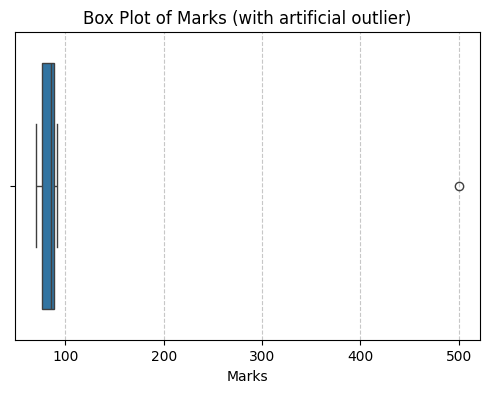

In [19]:
# For demonstration, let's artificially introduce an outlier in 'Marks' based on the PDF example.
outlier_data_example = data_filled.copy()
outlier_data_example.loc[2, 'Marks'] = 500  # Changing John's marks to 500

print("Box plot for 'Marks' (with artificial outlier):")
fig = plt.figure(figsize=(6, 4))
sns.boxplot(x=outlier_data_example["Marks"])
plt.title('Box Plot of Marks (with artificial outlier)')
plt.xlabel('Marks')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Step 7: Feature Selection (Conceptual)

The PDF describes the benefits of feature selection (faster training, reduced overfitting, improved interpretability) but does not provide a specific code example for direct implementation here, as it often depends on the specific machine learning task and dataset.

### Complete Preprocessing Example from Document

In [20]:
import pandas as pd

# Re-load dataset for a clean start for the complete example
# Ensure students.csv exists, which was created earlier.
data_complete_example = pd.read_csv("students.csv")
print("Original data for complete example (first 5 rows):")
display(data_complete_example.head())

# Check missing values
print("\nMissing values before handling:")
print(data_complete_example.isnull().sum())

# Fill missing values
# The PDF example uses data.mean() which will only work on numeric columns
# Adjusting to fill numeric with mean and categorical ('Gender') with mode.
data_complete_example.fillna(data_complete_example.mean(numeric_only=True), inplace=True)
data_complete_example["Gender"].fillna(data_complete_example["Gender"].mode()[0], inplace=True)

print("\nMissing values after filling:")
print(data_complete_example.isnull().sum())

# Remove duplicates
print("\nNumber of duplicate rows before removal:", data_complete_example.duplicated().sum())
data_complete_example.drop_duplicates(inplace=True)
print("Number of duplicate rows after removal:", data_complete_example.duplicated().sum())

# Encode categorical variables
# The PDF example uses pd.get_dummies(data) on the entire DataFrame.
# This will convert all suitable categorical columns ('Gender' and 'Color' in our case).
data_complete_example = pd.get_dummies(data_complete_example, columns=['Gender', 'Color'], drop_first=False)

print("\nProcessed data after all steps (first 5 rows):")
display(data_complete_example.head())

Original data for complete example (first 5 rows):


,RollNo,Name,Age,Marks,Gender,Color,Salary
0,101,Asha,20.0,85.0,F,Red,30000.0
1,102,Ravi,21.0,76.0,M,Blue,NaN
2,103,John,20.0,NaN,M,Green,35000.0
3,104,Meena,22.0,91.0,F,Red,40000.0
4,105,Peter,23.0,80.0,M,Blue,45000.0



Missing values before handling:
RollNo    0
Name      0
Age       1
Marks     1
Gender    1
Color     0
Salary    2
dtype: int64

Missing values after filling:
RollNo    0
Name      0
Age       0
Marks     0
Gender    0
Color     0
Salary    0
dtype: int64

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0

Processed data after all steps (first 5 rows):


/tmp/ipykernel_1755/2939363239.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_complete_example["Gender"].fillna(data_complete_example["Gender"].mode()[0], inplace=True)


,RollNo,Name,Age,Marks,Salary,Gender_F,Gender_M,Color_Blue,Color_Green,Color_Red
0,101,Asha,20.0,85.00,30000.000000,True,False,False,False,True
1,102,Ravi,21.0,76.00,37428.571429,False,True,True,False,False
2,103,John,20.0,81.25,35000.000000,False,True,False,True,False
3,104,Meena,22.0,91.00,40000.000000,True,False,False,False,True
4,105,Peter,23.0,80.00,45000.000000,False,True,True,False,False
